# Linux File Permissions — Expanded Edition

*A companion to `Lesson2-Linux_Basic_Permissions_Tutorial.ipynb`, with more depth, worked
diagrams, an interactive permission calculator, a full `umask` section, and a self-check quiz
with answers.*

**This notebook does not replace the original** — it exists alongside it as a deeper pass on the
same topic. If you only have five minutes, read the original. If you want the full picture
(including the parts that were missing — `umask`, symbolic `chmod` operators, troubleshooting,
and worked visuals), stay here.

### What's new compared to the original lesson
- A labelled diagram of every character in `ls -l` output
- A full 0–7 octal reference rendered as a colour-coded table, not just a markdown table
- **`umask`** — how default permissions are actually chosen (missing from the original entirely)
- Symbolic `chmod` operators (`u+x`, `g-w`, `o=r`, `a+X`, `+X` vs `+x`) — also missing before
- An interactive Python permission calculator you can call with any mode
- A visual access-decision flowchart (root → owner → group → other)
- A troubleshooting checklist for "Permission denied"
- Answers to the review questions (the original left them unanswered)

### How this notebook works
The kernel is Python 3, so real Linux shell commands are shown as **reference code blocks**
(` ```bash ... ``` `) — copy them into an actual Linux terminal, VM, or WSL session to see live
output. The diagrams and the permission calculator, on the other hand, are genuine Python code
cells: run them (or just read the pre-rendered output below) to see real, computed results.

## 1. Inodes and metadata, in more depth

Every file — including directories, symlinks, device nodes, and sockets — is represented on disk
by an **inode** (index node). The directory entry (the name you type) is just a pointer to an
inode number; the name itself is *not* stored inside the inode.

Fields commonly stored in an inode:

| Field | Meaning |
|---|---|
| Inode number | Unique identifier within the filesystem |
| File type | Regular file, directory, symlink, device, socket, FIFO |
| UID / GID | Numeric owner and group |
| Mode | 12 permission bits (9 regular + 3 special) + file-type bits |
| Link count | Number of hard links pointing at this inode |
| Size | Size in bytes |
| Timestamps | `atime` (access), `mtime` (modify), `ctime` (metadata change) |
| Pointers to data blocks | Where the actual file content lives on disk |

Notice what is **not** in this list: the filename. That's why a file can have several names
(hard links) pointing at the same inode, and why renaming a file is cheap — it only rewrites a
directory entry, never touches the inode's data blocks.

```bash
# See the inode number and raw metadata directly
ls -i file.txt
stat file.txt
```

In [1]:
# A quick mental model of an inode, expressed as a Python dict.
# This is illustrative only -- real inodes are binary kernel structures, not Python objects.
example_inode = {
    "inode_number": 132456,
    "file_type": "regular file",
    "uid": 1000,
    "gid": 1000,
    "mode_octal": "100644",   # 100000 = regular file marker, 644 = rw-r--r--
    "link_count": 1,
    "size_bytes": 4096,
    "atime": "2026-07-18 09:14:02",
    "mtime": "2026-07-17 22:03:11",
    "ctime": "2026-07-17 22:03:11",
}
for k, v in example_inode.items():
    print(f"{k:>13}: {v}")

 inode_number: 132456
    file_type: regular file
          uid: 1000
          gid: 1000
   mode_octal: 100644
   link_count: 1
   size_bytes: 4096
        atime: 2026-07-18 09:14:02
        mtime: 2026-07-17 22:03:11
        ctime: 2026-07-17 22:03:11


## 2. Root, and the three permission classes

- **root (UID 0)** bypasses almost all discretionary permission checks. A handful of operations
  (like executing a file with no `x` bit at all, or some mandatory-access-control policies under
  SELinux/AppArmor) can still block root, but ordinary `rwx` checks do not apply to it.
- **Owner (User)** — the UID stored in the file's inode.
- **Group** — any process whose *effective* GID, or one of its *supplementary* GIDs, matches the
  file's group.
- **Others (World)** — everyone else with access to the system.

### The access decision, as a flowchart

The kernel does **not** add up all matching permission sets — it stops at the *first* class that
applies, in this order: root → owner → group → other. This matters: if the owner's bits deny an
action, being in the right group does **not** save you, because the owner check already matched
(you *are* the owner) and the kernel never falls through to the group check.

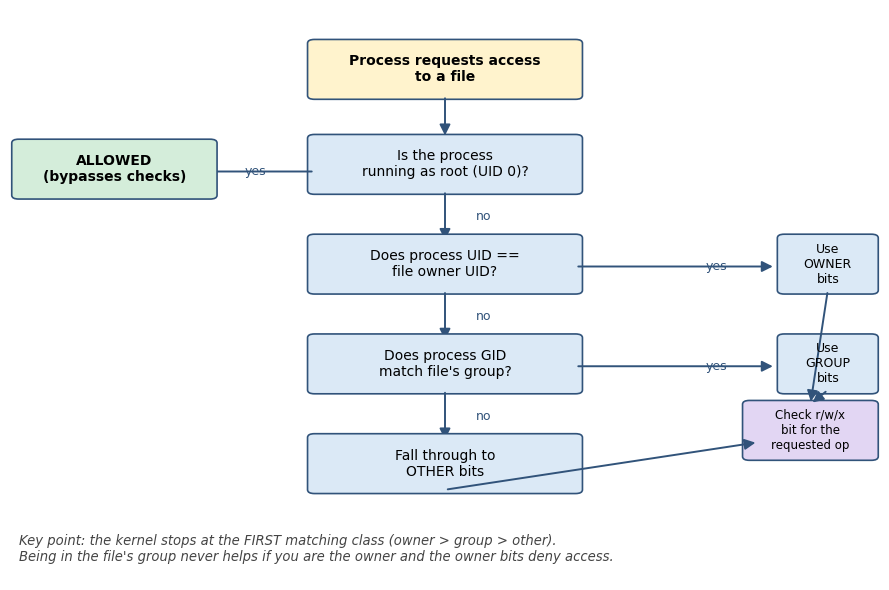

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis("off")

def box(x, y, w, h, text, color="#dbe9f6", fontsize=10, weight="normal"):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.08",
                        linewidth=1.2, edgecolor="#31537a", facecolor=color)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize,
             weight=weight, wrap=True)

def arrow(x1, y1, x2, y2, label=""):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=16,
                         linewidth=1.4, color="#31537a")
    ax.add_patch(a)
    if label:
        ax.text((x1+x2)/2 + 0.35, (y1+y2)/2, label, fontsize=9, color="#31537a", va="center")

box(3.5, 10.2, 3, 1.1, "Process requests access\nto a file", "#fff3cd", weight="bold")
arrow(5, 10.2, 5, 9.3)

box(3.5, 8.2, 3, 1.1, "Is the process\nrunning as root (UID 0)?", "#dbe9f6")
arrow(3.5, 8.6, 1.2, 8.6, "yes")
box(0.1, 8.1, 2.2, 1.1, "ALLOWED\n(bypasses checks)", "#d4edda", weight="bold")
arrow(5, 8.2, 5, 7.1, "no")

box(3.5, 6.1, 3, 1.1, "Does process UID ==\nfile owner UID?", "#dbe9f6")
arrow(6.5, 6.6, 8.8, 6.6, "yes")
box(8.9, 6.1, 1.0, 1.1, "Use\nOWNER\nbits", "#dbe9f6", fontsize=9)
arrow(5, 6.1, 5, 5.0, "no")

box(3.5, 4.0, 3, 1.1, "Does process GID\nmatch file's group?", "#dbe9f6")
arrow(6.5, 4.5, 8.8, 4.5, "yes")
box(8.9, 4.0, 1.0, 1.1, "Use\nGROUP\nbits", "#dbe9f6", fontsize=9)
arrow(5, 4.0, 5, 2.9, "no")

box(3.5, 1.9, 3, 1.1, "Fall through to\nOTHER bits", "#dbe9f6")

box(8.5, 2.6, 1.4, 1.1, "Check r/w/x\nbit for the\nrequested op", "#e2d6f3", fontsize=8.5)
arrow(9.4, 6.1, 9.2, 3.7)
arrow(9.4, 4.0, 9.2, 3.7)
arrow(5, 1.9, 8.6, 2.9)

ax.text(0.1, 0.4,
        "Key point: the kernel stops at the FIRST matching class (owner > group > other).\n"
        "Being in the file's group never helps if you are the owner and the owner bits deny access.",
        fontsize=9.5, style="italic", color="#444")

plt.tight_layout()
plt.savefig("access_decision_flow.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. The permission bits: r, w, x and their binary weights

Each class (owner/group/other) gets three bits. Each bit has a fixed weight, which is why octal
notation works so cleanly:

| Bit | Symbol | Weight | Binary |
|---|---|---:|---|
| read | `r` | 4 | `100` |
| write | `w` | 2 | `010` |
| execute | `x` | 1 | `001` |

Any combination is just the sum of the weights that are "on". `rwx` = 4+2+1 = **7**. `r-x` = 4+0+1
= **5**. `--- ` = **0**. Three classes, each 0–7, gives the familiar 3-digit octal mode like `754`.

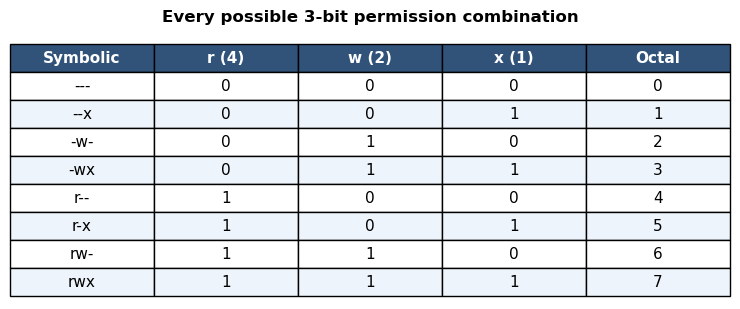

In [3]:
import matplotlib.pyplot as plt

combos = [
    ("---", 0), ("--x", 1), ("-w-", 2), ("-wx", 3),
    ("r--", 4), ("r-x", 5), ("rw-", 6), ("rwx", 7),
]

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.axis("off")
col_labels = ["Symbolic", "r (4)", "w (2)", "x (1)", "Octal"]
rows = []
for sym, val in combos:
    rows.append([sym, "1" if val & 4 else "0", "1" if val & 2 else "0", "1" if val & 1 else "0", str(val)])

table = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#31537a")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#eef4fb" if row % 2 == 0 else "#ffffff")

plt.title("Every possible 3-bit permission combination", fontsize=12, weight="bold", pad=14)
plt.tight_layout()
plt.savefig("octal_bit_table.png", dpi=140, bbox_inches="tight")
plt.show()

## 4. Reading `ls -l` and `stat`, field by field

```bash
$ ls -l hello.sh
-rwxr-xr-- 1 ali staff 177 Jul 5 23:28 hello.sh
```

The diagram below labels every character of the 10-character permission string, plus the
remaining `ls -l` fields.

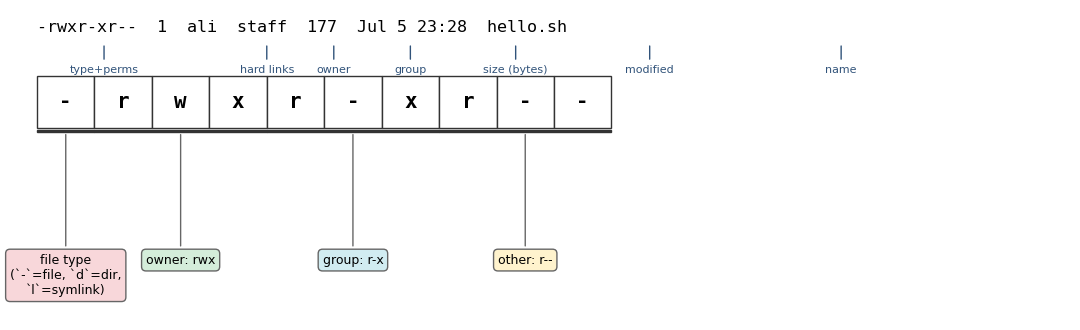

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4.2)
ax.axis("off")

perm_string = "-rwxr-xr--"
groups = [
    (0, 1, "file type\n(`-`=file, `d`=dir,\n`l`=symlink)", "#f8d7da"),
    (1, 4, "owner: rwx", "#d4edda"),
    (4, 7, "group: r-x", "#d1ecf1"),
    (7, 10, "other: r--", "#fff3cd"),
]

cell_w = 0.6
start_x = 0.2
for i, ch in enumerate(perm_string):
    x = start_x + i * cell_w
    ax.add_patch(plt.Rectangle((x, 2.6), cell_w, 0.7, edgecolor="#333", facecolor="white"))
    ax.text(x + cell_w/2, 2.95, ch, ha="center", va="center", fontsize=15, family="monospace", weight="bold")

for (s, e, label, color) in groups:
    x0 = start_x + s * cell_w
    x1 = start_x + e * cell_w
    ax.add_patch(plt.Rectangle((x0, 2.55), x1 - x0, 0.02, color="#333"))
    ax.annotate(label, xy=((x0+x1)/2, 2.55), xytext=((x0+x1)/2, 0.9),
                ha="center", va="top", fontsize=9,
                arrowprops=dict(arrowstyle="-", color="#666"),
                bbox=dict(boxstyle="round,pad=0.35", facecolor=color, edgecolor="#666"))

ax.text(0.2, 3.9, "-rwxr-xr--  1  ali  staff  177  Jul 5 23:28  hello.sh", fontsize=12,
        family="monospace")
fields = ["type+perms", "hard links", "owner", "group", "size (bytes)", "modified", "name"]
xs =    [0.9,           2.6,          3.3,     4.1,     5.2,             6.6,        8.6]
for f, x in zip(fields, xs):
    ax.annotate(f, xy=(x, 3.75), xytext=(x, 3.35), ha="center", fontsize=8, color="#31537a",
                arrowprops=dict(arrowstyle="-", color="#31537a"))

plt.tight_layout()
plt.savefig("ls_l_anatomy.png", dpi=140, bbox_inches="tight")
plt.show()

`stat` shows the same information in far more detail, including both symbolic and octal modes,
raw timestamps, and the inode number:

```bash
$ stat hello.sh
  File: hello.sh
  Size: 177             Blocks: 8          IO Block: 4096   regular file
Device: 803h/2051d      Inode: 132456      Links: 1
Access: (0754/-rwxr-xr--)  Uid: ( 1000/    ali)   Gid: ( 1000/  staff)
Access: 2026-07-18 09:14:02.000000000 +0000
Modify: 2026-07-17 22:03:11.000000000 +0000
Change: 2026-07-17 22:03:11.000000000 +0000
 Birth: -
```

Useful `stat` format shortcuts:

```bash
stat -c '%A %a %U %G %n' file.txt   # symbolic, octal, owner, group, name -- one line
stat -c '%s bytes'      file.txt    # size only
stat --format='%Y'      file.txt    # mtime as a Unix timestamp
```

## 5. Numeric (octal) permissions, and symbolic `chmod` operators

### 5.1 Octal notation

|Number|Meaning|
|---:|---|
|0|`---`|
|1|`--x`|
|2|`-w-`|
|3|`-wx`|
|4|`r--`|
|5|`r-x`|
|6|`rw-`|
|7|`rwx`|

`chmod 0755 file` sets owner=`rwx`, group=`rx`, other=`rx`. The leading `0` is the (usually
omitted) special-bits digit — see the special-permissions notebook for what a non-zero value
there means.

### 5.2 Symbolic operators (the part the original lesson skipped)

`chmod` also accepts a symbolic form: `chmod [ugoa][+-=][rwx] target`.

| Piece | Meaning |
|---|---|
| `u` `g` `o` `a` | user(owner) / group / other / all |
| `+` | add the listed permission(s), leave everything else alone |
| `-` | remove the listed permission(s), leave everything else alone |
| `=` | set *exactly* these permission(s), clearing anything else in that class |
| `X` (capital) | add execute **only if** it's already a directory, or already executable for *someone* |

```bash
chmod u+x script.sh        # owner gains execute; group/other untouched
chmod g-w file.txt         # group loses write; owner/other untouched
chmod o=r file.txt         # other becomes exactly read-only
chmod a+r shared.conf      # everyone gains read
chmod -R a+X project/      # recursively let everyone traverse directories,
                            # without making plain files executable
chmod u=rwx,g=rx,o=r file  # set all three classes explicitly in one call
```

Symbolic mode is often *safer* for scripts and one-off tweaks because `+`/`-` only touch the bit
you name — a numeric `chmod 644` silently overwrites *all nine* bits, which can accidentally
remove an execute bit you didn't mean to touch.

In [5]:
def explain_mode(mode):
    '''Accepts an octal string ('0755', '644') or a 9/10-char symbolic string
    ('rwxr-xr-x', '-rwxr-xr--') and prints a full breakdown.'''
    classes = ["owner", "group", "other"]

    if all(c in "01234567" for c in mode) and len(mode) in (3, 4):
        digits = mode[-3:]
        special = mode[0] if len(mode) == 4 else "0"
        bits = [int(d) for d in digits]
    else:
        sym = mode[1:] if len(mode) == 10 else mode
        assert len(sym) == 9, "expected 9 rwx characters"
        bits = []
        for i in range(3):
            chunk = sym[i*3:(i+1)*3]
            val = (4 if chunk[0] == "r" else 0) | (2 if chunk[1] == "w" else 0) | (1 if chunk[2] == "x" else 0)
            bits.append(val)
        special = "0"

    print(f"Input: {mode!r}")
    print(f"Octal: {special}{bits[0]}{bits[1]}{bits[2]}")
    symbolic = "".join(
        ("r" if v & 4 else "-") + ("w" if v & 2 else "-") + ("x" if v & 1 else "-")
        for v in bits
    )
    print(f"Symbolic: {symbolic}")
    print()
    for cls, v in zip(classes, bits):
        r = "read" if v & 4 else None
        w = "write" if v & 2 else None
        x = "execute" if v & 1 else None
        allowed = ", ".join(p for p in (r, w, x) if p) or "nothing"
        print(f"  {cls:>5}: {v}  ->  {allowed}")

explain_mode("0754")
print("\n" + "-"*40 + "\n")
explain_mode("rwxr-xr--")

Input: '0754'
Octal: 0754
Symbolic: rwxr-xr--

  owner: 7  ->  read, write, execute
  group: 5  ->  read, execute
  other: 4  ->  read

----------------------------------------

Input: 'rwxr-xr--'
Octal: 0754
Symbolic: rwxr-xr--

  owner: 7  ->  read, write, execute
  group: 5  ->  read, execute
  other: 4  ->  read


## 6. `umask` — the piece the original lesson left out entirely

New files and directories don't appear with `777`/`666` by default. The kernel starts from a
**base mode** and subtracts whatever bits are set in the process's **`umask`**.

- New **regular files** start from base `666` (`rw-rw-rw-`) — the kernel never grants execute on
  a freshly created file, regardless of umask, because most files aren't meant to be run.
- New **directories** start from base `777` (`rwxrwxrwx`), since directories usually need `x` to
  be enterable.

```
final_mode = base_mode  &  ~umask
```

The umask **removes** bits — it can never add a permission that wasn't in the base mode.

### Worked example: `umask 022`

| | Owner | Group | Other |
|---|---|---|---|
| Base (dir)  777 | rwx | rwx | rwx |
| umask 022       | --- | -w- | -w- |
| **Result** 755  | rwx | r-x | r-x |
| Base (file) 666 | rw- | rw- | rw- |
| umask 022       | --- | -w- | -w- |
| **Result** 644  | rw- | r-- | r-- |

`umask 022` is the common single-user default: group and other lose write access, but keep read
(and, for directories, traverse).

```bash
umask            # show current umask
umask 027        # set it for this shell session (group loses write, other loses everything)
umask -S          # show it in symbolic form, e.g. u=rwx,g=rx,o=
```

To make a umask permanent, set it in a shell startup file (`~/.bashrc`, `~/.profile`, or
`/etc/profile` for a system-wide default).

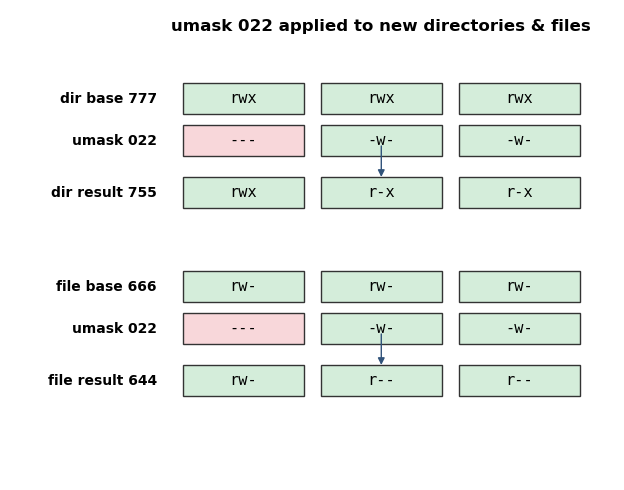

umask 022 -> new dir mode:  0o755
umask 022 -> new file mode: 0o644


In [6]:
import matplotlib.pyplot as plt

def bits(mode):
    return [(mode >> 6) & 7, (mode >> 3) & 7, mode & 7]

def render(ax, label, values, y):
    classes = ["owner", "group", "other"]
    ax.text(-0.3, y, label, ha="right", va="center", fontsize=10, weight="bold")
    for i, (cls, v) in enumerate(zip(classes, values)):
        sym = ("r" if v & 4 else "-") + ("w" if v & 2 else "-") + ("x" if v & 1 else "-")
        color = "#d4edda" if v else "#f8d7da"
        ax.add_patch(plt.Rectangle((i*1.6, y-0.3), 1.4, 0.6, facecolor=color, edgecolor="#333"))
        ax.text(i*1.6 + 0.7, y, sym, ha="center", va="center", fontsize=11, family="monospace")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.set_xlim(-2, 5)
ax.set_ylim(-0.5, 8.5)
ax.axis("off")

umask_val = 0o022
base_dir, base_file = 0o777, 0o666
result_dir = base_dir & ~umask_val
result_file = base_file & ~umask_val

ax.text(2.3, 8.1, "umask 022 applied to new directories & files", fontsize=12, weight="bold", ha="center")

render(ax, "dir base 777", bits(base_dir), 6.8)
render(ax, "umask 022", bits(umask_val), 6.0)
render(ax, "dir result 755", bits(result_dir), 5.0)

render(ax, "file base 666", bits(base_file), 3.2)
render(ax, "umask 022", bits(umask_val), 2.4)
render(ax, "file result 644", bits(result_file), 1.4)

for y in (5.4, 1.8):
    ax.annotate("", xy=(2.3, y-0.15), xytext=(2.3, y+0.55),
                arrowprops=dict(arrowstyle="-|>", color="#31537a"))

plt.tight_layout()
plt.savefig("umask_demo.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"umask 022 -> new dir mode:  {oct(result_dir)}")
print(f"umask 022 -> new file mode: {oct(result_file)}")

In [7]:
def apply_umask(umask_octal, is_directory=False):
    base = 0o777 if is_directory else 0o666
    result = base & ~umask_octal
    kind = "directory" if is_directory else "file"
    print(f"umask {oct(umask_octal)[2:]:>3}  x  {kind} base {oct(base)[2:]}  ->  {oct(result)[2:]}")
    return result

for u in (0o022, 0o002, 0o077, 0o000):
    apply_umask(u, is_directory=True)
    apply_umask(u, is_directory=False)
    print()

umask  22  x  directory base 777  ->  755
umask  22  x  file base 666  ->  644

umask   2  x  directory base 777  ->  775
umask   2  x  file base 666  ->  664

umask  77  x  directory base 777  ->  700
umask  77  x  file base 666  ->  600

umask   0  x  directory base 777  ->  777
umask   0  x  file base 666  ->  666



## 7. File vs. directory semantics (expanded)

|Permission|On a file|On a directory|
|---|---|---|
|`r`|Read contents (`cat`, `less`, `cp` as source)|List entry **names** (`ls`) — but not their metadata unless you can also `stat` each entry|
|`w`|Modify contents (needs `r` too, typically, for editors)|Create, delete, or rename entries **inside** it (needs `x` too)|
|`x`|Run as a program/script (needs a valid shebang or be a real binary)|**Enter** it (`cd`) and resolve/access entries **by exact name**, even without `r`|

Worked scenarios:

- `r--` on a file → `cat`/`cp` work; editors that try to open for writing fail; running it fails
  even if it's a script, because execute is off.
- `--x` on a file → the kernel will attempt to execute it (rare, but valid) yet `cat` fails.
- `r-x` on a directory → `ls` works, `cd` works, reading known files inside works; creating or
  deleting entries fails.
- `--x` on a directory → you **cannot** `ls` it (no names listed) but if you already know a
  filename inside it, you can still `cd` into it or open that file directly. This is the basis of
  "private" home directories on some systems: `~` might be `711` so others can reach a
  specifically-shared subfolder without browsing everything else.
- `-wx` on a directory (no `r`) → you can create/delete/rename entries whose names you already
  know, but `ls` shows nothing.

**Deleting, renaming, or moving a file is a *directory* operation**, not a file operation. A
read-only file (`r--`) inside a directory you can write to (`rwx`) can still be deleted — the
kernel is unlinking a directory entry, not modifying the file's own data. This surprises almost
everyone the first time they hit it. (The special-permissions notebook covers the fix: the
**sticky bit**.)

## 8. `chmod`, `chown`, `chgrp` — full reference

```bash
# chmod: change permission bits. Owner may change their own file's mode; root always can.
chmod 644 file.txt
chmod u+x script.sh
chmod -R 755 project/          # -R = recurse into subdirectories

# chown: change owner (and optionally group). Normally root-only.
sudo chown alice file.txt
sudo chown alice:developers file.txt
sudo chown :developers file.txt     # change group only, via chown
sudo chown -R alice:developers dir/

# chgrp: change group only. Root can always do it; an owner can often change to a
# group they already belong to (varies slightly by distro policy).
chgrp developers file.txt
chgrp -R developers project/
```

### Practical / edge-case modes

| Command | Effect |
|---|---|
| `chmod 000 important.txt` | Nobody but root can access it — a blunt "freeze" for a file |
| `chmod 200 file` | Owner: write-only. Can overwrite/truncate, cannot read back |
| `chmod 100 file` | Owner: execute-only. Only useful for a runnable binary/script |
| `chmod 100 dir` | Can `cd` in if the name is known, cannot list or create/delete entries |
| `chmod 500 dir` | Practical minimum for a directory people need to browse: `r-x`, no writes |
| `chmod 777 anything` | Everyone can read/write/execute — almost always a mistake outside `/tmp`-style sticky directories |

In [8]:
def audit_mode(octal_str):
    '''Flag common risky permission patterns, similar in spirit to a lightweight lint check.'''
    mode = int(octal_str, 8)
    warnings = []
    if mode & 0o002:
        warnings.append("world-writable: any local user can modify this")
    if mode & 0o022 == 0o022 and mode & 0o111:
        warnings.append("world-writable AND executable -- a classic tamper vector")
    if mode == 0o777:
        warnings.append("777: full access for everyone, rarely intentional")
    if mode & 0o100 and not mode & 0o400:
        warnings.append("executable without owner-read -- owner can run it but not inspect it")
    if not warnings:
        warnings.append("no obvious red flags")
    print(f"{octal_str} ({oct(mode)}):")
    for w in warnings:
        print(f"  - {w}")

for m in ["644", "755", "777", "600", "100", "0666"]:
    audit_mode(m)

644 (0o644):
  - no obvious red flags
755 (0o755):
  - no obvious red flags
777 (0o777):
  - world-writable: any local user can modify this
  - world-writable AND executable -- a classic tamper vector
  - 777: full access for everyone, rarely intentional
600 (0o600):
  - no obvious red flags
100 (0o100):
  - executable without owner-read -- owner can run it but not inspect it
0666 (0o666):
  - world-writable: any local user can modify this


## 9. Worked example — a real directory listing

```
-rwxrwxrwx 1 ali ali    27 Jul  5 23:31 a.txt
-rw-rw-r-- 1 ali ali    36 Jul  5 23:31 b.txt
-rw-rw-r-- 1 ali ali     0 Jul  6 02:12 bar
-rwxrwxr-x 1 ali ali   177 Jul  5 23:28 count_words.sh
-rw-rw-r-- 1 ali ali     0 Jul  5 22:39 fee
drwxrwxr-x 2 ali ali  4096 Jul  6 00:08 foo
-rwxrwxr-x 2 ali ali 70448 Jul  6 01:03 hello
-rw-rw-r-- 1 ali ali    64 Jul  6 01:03 hello.c
```

| File | Octal | Read | Risk / notes |
|---|---|---|---|
| `a.txt` | 777 | world read/write/execute | unsafe — any local user can overwrite it |
| `b.txt` | 664 | owner+group read/write, others read-only | normal shared-project file |
| `bar` | 664 | same as `b.txt` | empty placeholder file, same policy |
| `count_words.sh` | 775 | owner+group can execute | reasonable for a shared team script |
| `fee` | 664 | — | empty file, unremarkable |
| `foo` | 775 | it's a **directory** (`d…`) | owner+group can create/delete entries inside |
| `hello` | 775, link count **2** | executable binary | two hard links point at the same inode — check `hello.c` isn't accidentally the same file |
| `hello.c` | 664 | — | C source, not executable (correct — it needs to be compiled first) |

Note the `2` in `hello`'s link-count column: that file has **two directory entries** pointing to
the same inode somewhere on this filesystem (a hard link). Deleting one name would not free the
data — the other name would still work.

## 10. Troubleshooting "Permission denied"

A checklist, roughly in the order worth checking:

1. **Whose file is it, and who are you?** `id` shows your UID/GID(s); `ls -l` or `stat` shows the
   file's owner/group.
2. **Which class actually applies to you?** Remember: owner-vs-group-vs-other is first-match, not
   cumulative (see the flowchart above).
3. **Is the *directory* permission the real blocker?** `cd`, create, delete, and rename are
   directory operations — checking only the file's own bits misses this.
4. **Every directory in the path needs `x`.** `/a/b/c.txt` requires execute (traverse) on `/`,
   `/a`, and `/a/b` — not just on `c.txt`'s immediate parent.
5. **Is the filesystem mounted `noexec`, `nosuid`, or read-only?** `mount | grep <mountpoint>` or
   `findmnt <path>` shows active mount options that can override what `ls -l` implies.
6. **Are you actually the user you think you are?** `sudo -u otheruser id`, or check if you're
   inside a container/namespace with different UID mapping.
7. **ACLs or security modules.** `getfacl file` shows POSIX ACLs that can grant/deny beyond the
   classic 9 bits; SELinux/AppArmor can deny access even when standard permissions allow it —
   check `dmesg` / `journalctl` / `audit.log` for denials in that case.

```bash
id                          # who am i, really (uid, gid, groups)
namei -l /a/b/c.txt         # show permissions for every path component
getfacl file.txt            # check for extra ACL entries
mount | grep " / "          # check mount options on the root filesystem
```

## 11. Hands-on lab

Run these on a real Linux machine, VM, or WSL terminal (not this Python kernel):

```bash
mkdir -p perm_lab && cd perm_lab

touch demo.txt
mkdir demo_dir
umask                       # note your current default

chmod 644 demo.txt
chmod 755 demo_dir
ls -l demo.txt
ls -ld demo_dir
stat -c '%A %a %U %G %n' demo.txt demo_dir

chmod u+x demo.txt          # add owner-execute symbolically
ls -l demo.txt
chmod u-x demo.txt          # remove it again

echo "secret" > secret.txt
chmod 600 secret.txt        # owner-only read/write
ls -l secret.txt

chmod 444 demo.txt          # read-only for everyone
echo "test" >> demo.txt     # expect: Permission denied
rm demo.txt                 # but deletion still works if the *directory* allows it
```

Predict the output of each command **before** running it, then compare.

## 12. A note for readers coming from Windows

Since this notebook runs on a Windows machine, it's worth naming the difference explicitly:
Windows' native permission model is **NTFS ACLs** (Access Control Lists) — an arbitrary list of
`(user or group, allow/deny, specific rights)` entries per file, checked in order, with explicit
deny able to override an earlier allow.

Linux's classic 9-bit model is far simpler: exactly three fixed classes (owner/group/other),
first-match-wins, no explicit "deny" entries. It trades flexibility for predictability and a
tiny, fixed-size metadata footprint. When Linux *does* need Windows-ACL-style flexibility, it
layers **POSIX ACLs** (`setfacl`/`getfacl`) on top of the same 9 bits rather than replacing them.
If you use WSL, `wsl.exe` maps NTFS permissions onto a Linux-like view, but the underlying
enforcement is still NTFS — worth remembering if `chmod` inside WSL looks like it "didn't stick"
on a `/mnt/c/...` path.

## 13. Review questions

1. Why is deleting a file controlled by the directory's permissions rather than the file's own?
2. What's the practical difference between `644` and `755`?
3. Why is `777` usually dangerous, and when (if ever) is it acceptable?
4. What does `chmod 200 file` leave you able to do?
5. Why does root usually ignore permission bits, and name one thing that can still stop root.
6. When would `chmod 000` be a reasonable thing to do?
7. What does `-R` do, and what's a scenario where using it carelessly causes damage?
8. What's the difference between `chown` and `chgrp`?
9. What does `umask 022` produce for a new file, and for a new directory? Show the arithmetic.
10. Why does `chmod +x` sometimes feel "safer" than `chmod 755`?
11. A directory is `--x` for other. Can a user outside owner/group `ls` it? Can they open a file
    inside it if they already know its name?
12. Your script has `-rw-r--r--`. You run `./script.sh` and get "Permission denied". Diagnose it.

### Answers

1. Deletion/rename removes or changes a *directory entry*, which is data that lives in the parent
   directory, not in the file's own inode — so the parent directory's `w`+`x` bits govern it.
2. `644` (`rw-r--r--`) is for data files: everyone can read, only the owner can write, nobody can
   execute. `755` (`rwxr-xr-x`) additionally lets everyone execute — appropriate for programs and
   scripts, not for plain data.
3. It grants read/write/execute to literally every local user. It's rarely correct outside of
   sticky, publicly-writable scratch directories (`/tmp`-style, and even those use `1777`, not
   `0777`, precisely to avoid this problem for file deletion).
4. Only overwrite/truncate the file's contents (write). You cannot read it back, and you cannot
   execute it.
5. Root bypasses the classic 9-bit discretionary checks. It does **not** automatically bypass
   mandatory access control (SELinux/AppArmor policy), immutable file attributes (`chattr +i`),
   or execution blocked by a `noexec` mount.
6. Temporarily "freezing" a file so absolutely nobody (but root) can touch it — e.g. protecting a
   sensitive file mid-incident-response without deleting it.
7. It applies the mode recursively to every file and subdirectory. Careless use (e.g. `chmod -R
   755 /` on the wrong path) can strip execute bits from data files or grant execute where it was
   never wanted, breaking scripts or exposing files.
8. `chown` changes the owner (and can optionally change the group in the same call via
   `user:group`); `chgrp` changes only the group.
9. File: base `666` minus `022` = `644`. Directory: base `777` minus `022` = `755`. (Bitwise: base
   AND NOT umask, per class.)
10. `chmod +x` only touches the execute bit and leaves read/write untouched; `chmod 755` rewrites
    all nine bits at once, silently resetting anything unusual (like a `640` you meant to keep).
11. They cannot list it, but they *can* still access a file inside it directly if they already
    know the exact filename — `--x` blocks browsing, not lookup-by-name.
12. Almost certainly the execute bit is missing on the file itself (`rw-r--r--` has no `x`
    anywhere) — fix with `chmod u+x script.sh`. (If that's not it, check the shebang line and the
    mount's `noexec` option next.)

## 14. Cheat sheet

```
r = 4   w = 2   x = 1        classes, in order: owner  group  other
final_mode = base_mode & ~umask        (files base 666, dirs base 777)

chmod 644 file        # rw-r--r--
chmod 755 dir_or_bin   # rwxr-xr-x
chmod u+x file         # add owner-execute only
chmod g-w file         # remove group-write only
chmod o=r file         # set other to exactly read-only
chmod -R a+X dir/       # let everyone traverse directories, without over-granting exec on files

chown user file
chown user:group file
chgrp group file

umask            # show current default mask
umask 022        # typical single-user default

stat -c '%A %a %U %G %n' file    # symbolic + octal + owner + group + name, one line
getfacl file                      # check for POSIX ACLs beyond the classic 9 bits
namei -l /a/b/c                   # audit every path component's permissions at once
```

**One-line mental model:** *access is decided by exactly one class (root, then owner, then
group, then other, first match wins), each class is 3 bits worth 4/2/1, files start from 666 and
directories from 777 before `umask` subtracts from them, and deleting/renaming is always a
directory operation.*